In [1]:
pip install pmdarima

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.7 MB/s eta 0:00:00


In [2]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.metrics import r2_score

In [3]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
data = pd.read_csv(io.StringIO(uploaded['US Soybeans Futures Historical Data.csv'].decode('utf-8')))

Saving US Soybeans Futures Historical Data.csv to US Soybeans Futures Historical Data.csv


In [7]:
# Converting "Price", "Open", "High", "Low", "Vol." columns to float datatype
data['Price'] = data['Price'].str.replace(',', '').astype(float)
data['Open'] = data['Open'].str.replace(',', '').astype(float)
data['High'] = data['High'].str.replace(',', '').astype(float)
data['Low'] = data['Low'].str.replace(',', '').astype(float)
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000.
print(data.dtypes)

Date         object
Price       float64
Open        float64
High        float64
Low         float64
Vol.        float64
Change %     object
dtype: object


<Axes: >

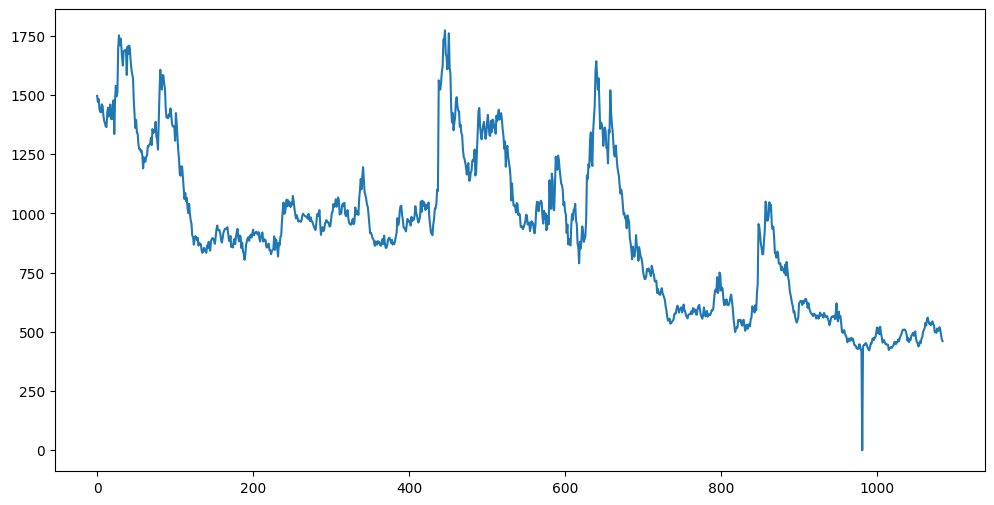

In [8]:
data["Open"].plot(figsize=(12,6))

In [9]:
# Dickey - Fuller Test
from statsmodels.tsa.stattools import adfuller

def ad_test(dataset):
  dftest = adfuller(dataset, autolag ='AIC')
  print("1. ADF: ", dftest[0])
  print("2. p-value: ", dftest[1])
  print("3. No. of lags: ", dftest[2])
  print("4. No. of observations used for ADF Regression and Critical Values Calculations: ", dftest[3])
  print("5. Critical Values: ")
  for key, val in dftest[4].items():
    print("\t", key, ",", val)

In [10]:
ad_test(data['Price'])

1. ADF:  -2.31363348533143
2. p-value:  0.16760859540306816
3. No. of lags:  12
4. No. of observations used for ADF Regression and Critical Values Calculations:  1072
5. Critical Values: 
	 1% , -3.4364647646486093
	 5% , -2.864239892228526
	 10% , -2.5682075189699822


In [11]:
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

In [12]:
stepwise_fit = auto_arima(data['Price'], trace=True, suppress_warnings=True)
stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=11128.629, Time=2.37 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=11146.970, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=11136.407, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=11138.789, Time=0.59 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=11145.569, Time=0.11 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=11126.674, Time=1.73 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=11124.685, Time=0.77 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=11126.676, Time=1.24 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=11129.350, Time=3.13 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=11128.431, Time=2.77 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=11123.269, Time=0.38 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=11137.507, Time=0.40 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=11125.262, Time=1.06 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=11125.263, Time=0.57 sec
 ARIMA(1,1,1)(0,0,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1085
Model:               SARIMAX(0, 1, 2)   Log Likelihood               -5558.635
Date:                Sun, 11 Jun 2023   AIC                          11123.269
Time:                        04:48:44   BIC                          11138.234
Sample:                             0   HQIC                         11128.935
                               - 1085                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0961      0.016     -6.191      0.000      -0.126      -0.066
ma.L2          0.1231      0.018      6.855      0.000       0.088       0.158
sigma2      1665.4719     28.829     57.770      0.000    1608.967    1721.977
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             17410.05
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               0.56   Skew:                             1.85
Prob(H) (two-sided):                  0.00   Kurtosis:                        22.28
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [13]:
# Convert the "date" column to a datetime object
data['Date'] = pd.to_datetime(data['Date'])

In [14]:
# Drop the columns you don't need
data = data.drop(["Change %"], axis=1)

In [15]:
import statsmodels.api as sm

In [16]:
"""
# Spllitting the dataset
print(data.shape)
train=data.iloc[:-30]
test=data.iloc[-30:]
print(train.shape, test.shape)
"""

'\n# Spllitting the dataset\nprint(data.shape)\ntrain=data.iloc[:-30]\ntest=data.iloc[-30:]\nprint(train.shape, test.shape)\n'

In [17]:
# extract features and target
X = data[['Open', 'High', 'Low','Vol.']]
y = data['Price']

In [18]:
# Addition
# Select the rows for the training set (2000-2019)
train_X = X[data['Date'].dt.year.between(2000, 2019)]
train_y = y[data['Date'].dt.year.between(2000, 2019)]

# Select the rows for the test set (2020-2022)
test_X = X[data['Date'].dt.year.between(2020, 2022)]
test_y = y[data['Date'].dt.year.between(2020, 2022)]

In [19]:
# Taining the model
model=sm.tsa.arima.ARIMA(train_y, order=(1,0,5))
model=model.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Price   No. Observations:                  929
Model:                 ARIMA(1, 0, 5)   Log Likelihood               -4754.613
Date:                Sun, 11 Jun 2023   AIC                           9525.226
Time:                        04:50:05   BIC                           9563.899
Sample:                             0   HQIC                          9539.977
                                - 929                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        865.6374    204.775      4.227      0.000     464.286    1266.989
ar.L1          0.9906      0.005    191.946      0.000       0.980       1.001
ma.L1         -0.0851      0.018     -4.630      0.000      -0.121      -0.049
ma.L2          0.1338      0.020      6.685      0.000       0.095       0.173
ma.L3         -0.0130      0.020     -0.652      0.515      -0.052       0.026
ma.L4          0.0173      0.023      0.756      0.450      -0.028       0.062
ma.L5         -0.0678      0.021     -3.220      0.001      -0.109      -0.027
sigma2      1625.8572     30.972     52.494      0.000    1565.153    1686.561
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             22275.77
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.45   Skew:                             2.29
Prob(H) (two-sided):                  0.00   Kurtosis:                        26.55
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [20]:
# Make predictions on the Test dataset
start = len(test_y)
end = len(test_y) + len(test_y)-1
pred = model.predict(start=start, end=end, type='levels')
print(pred)
pred.index = data.index[start:end+1]
print(pred)

312    1044.701114
313     997.543689
314     995.880232
315     988.857155
316    1029.528090
          ...     
463    1499.490823
464    1452.408616
465    1426.520359
466    1393.266001
467    1358.201365
Name: predicted_mean, Length: 156, dtype: float64
156    1044.701114
157     997.543689
158     995.880232
159     988.857155
160    1029.528090
          ...     
307    1499.490823
308    1452.408616
309    1426.520359
310    1393.266001
311    1358.201365
Name: predicted_mean, Length: 156, dtype: float64


<Axes: >

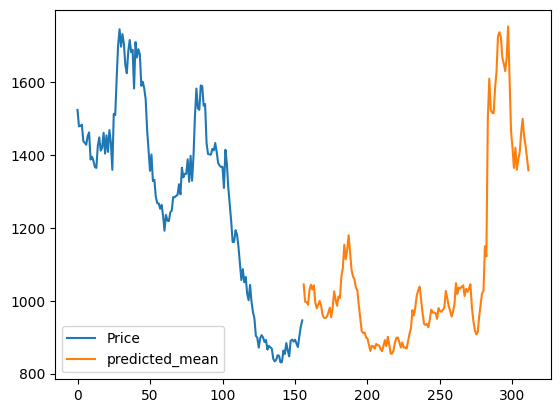

In [21]:
# Plotting the predicted values and the test set
test_y.plot(legend=True)
pred.plot(legend=True)

In [22]:
test_y.mean()

1282.8141025641025

In [23]:
from sklearn.metrics import mean_squared_error
from math import sqrt

rmse=sqrt(mean_squared_error(test_y, pred))
print(rmse)

501.39266859416836
